# MMN#


submitted by: ******

date: ********


# Question 1 


## **1.1 - 1.3**

We will implement the forward pass of our "SplitLinear" a model layer. This layer will take an NXM input tensor and split it in 2 equal parts along the feature dimension. Each part will then be passed through a separate linear aggregation layer and follow to a ReLu activation, and the outputs of these layers will be concatenated to produce the final Y output size NXM. 


In [1]:
import torch
import torch.nn as nn

class SplitLinear(nn.Module):
    """
    SplitLinear layer:
    - Input:  X of shape (N, M)
    - Split:  X_left = X[:, :M/2], X_right = X[:, M/2:]
    - Shared: apply the SAME Linear (M/2 -> M/2) to both halves
    - ReLU:   apply ReLU after the linear
    - Output: concatenate back to shape (N, M)
    """
    def __init__(self, M: int, bias: bool = True):
        # 1.2 Initialize the SplitLinear constructor
        super().__init__()
        if M % 2 != 0:
            raise ValueError(f"M must be even, got M={M}")
        
        self.M = M
        self.half = M // 2
        
        # Shared aggregation layer + activation
        self.linear = nn.Linear(self.half, self.half, bias=bias)
        self.relu = nn.ReLU()

        # Explicit initialization (do not rely on default reset_parameters)
        self._init_params()

    def _init_params(self):
        bound = 1.0 / (self.half ** 0.5) # 1/sqrt(M/2)
        nn.init.uniform_(self.linear.weight, -bound, bound) # Initialize weights uniformly
        if self.linear.bias is not None:
            nn.init.zeros_(self.linear.bias)


    def forward(self, X: torch.Tensor) -> torch.Tensor:
        # 1.1 implementation of the forward pass
        # Validate shape: must be (N, M)
        if X.dim() != 2:
            raise ValueError(f"Expected 2D input (N, M). Got shape {tuple(X.shape)}")
        if X.size(1) != self.M:
            raise ValueError(f"Expected input feature dim M={self.M}. Got {X.size(1)}")

        # Split along feature dimension
        X_left = X[:, :self.half]
        X_right = X[:, self.half:]

        # Shared linear + ReLU
        Z_left = self.linear(X_left)
        Z_right = self.linear(X_right)

        A_left = self.relu(Z_left)
        A_right = self.relu(Z_right)

        # Concatenate back
        Y = torch.cat([A_left, A_right], dim=1)

        return Y



#### Explanation of the `SplitLinear` Layer

The `SplitLinear` module implements a custom neural network layer that operates on inputs of shape $(N, M)$, where $ N $ is the batch size and $ M $ is the number of features. Since the layer splits the feature dimension into two equal parts, $ M $ is required to be even.

The constructor initializes a single linear layer that maps vectors of size $ \frac{M}{2} $ to $ \frac{M}{2} $, followed by a ReLU activation. This linear layer is **shared** between both halves of the input, enforcing weight sharing as required by the assignment.

Weights are initialized explicitly from a uniform distribution
$$
W_{ij} \sim \mathcal{U}\left(-\frac{1}{\sqrt{d}}, \frac{1}{\sqrt{d}}\right), \quad b = 0,
$$
where  $d = \frac{M}{2}$. This initialization breaks symmetry between neurons and keeps the scale of activations bounded at the start of training.

In the forward pass, the input is split along the feature dimension into two tensors of shape $(N, \frac{M}{2})$. Each half is passed through the shared linear layer and ReLU activation independently, and the resulting tensors are concatenated to produce an output of shape $(N, M)$, matching the input dimensionality.

In [2]:
def demo_splitlinear():
    torch.manual_seed(0)

    N, M = 3, 6
    layer = SplitLinear(M)

    X = torch.randn(N, M)
    print("X shape:", X.shape)
    print("X:\n", X)

    # manually reproduce the forward steps to print intermediates
    half = M // 2
    X_left = X[:, :half]
    X_right = X[:, half:]

    print("\nX_left:\n", X_left)
    print("\nX_right:\n", X_right)

    Z_left = layer.linear(X_left)
    Z_right = layer.linear(X_right)

    print("\nZ_left = Linear(X_left):\n", Z_left)
    print("\nZ_right = Linear(X_right):\n", Z_right)

    A_left = layer.relu(Z_left)
    A_right = layer.relu(Z_right)

    print("\nA_left = ReLU(Z_left):\n", A_left)
    print("\nA_right = ReLU(Z_right):\n", A_right)

    Y = torch.cat([A_left, A_right], dim=1)
    print("\nY = concat(A_left, A_right):\n", Y)
    print("\nY shape:", Y.shape)

    # sanity check: compare to actual forward
    Y2 = layer(X)
    print("\nMax |Y - layer(X)|:", (Y - Y2).abs().max().item())

demo_splitlinear()


X shape: torch.Size([3, 6])
X:
 tensor([[-1.5551, -0.3414,  0.4412, -0.2159, -0.7425,  0.5627],
        [ 0.2596, -0.1740, -0.6787,  0.9383, -1.5867,  1.2032],
        [ 0.0845, -1.2001, -0.0048, -0.5181, -0.3067, -1.5810]])

X_left:
 tensor([[-1.5551, -0.3414,  0.4412],
        [ 0.2596, -0.1740, -0.6787],
        [ 0.0845, -1.2001, -0.0048]])

X_right:
 tensor([[-0.2159, -0.7425,  0.5627],
        [ 0.9383, -1.5867,  1.2032],
        [-0.5181, -0.3067, -1.5810]])

Z_left = Linear(X_left):
 tensor([[ 0.8833,  0.0417,  0.7870],
        [ 0.0849, -0.2693, -0.2002],
        [ 0.4134, -0.2738,  0.2676]], grad_fn=<AddmmBackward0>)

Z_right = Linear(X_right):
 tensor([[ 0.2691,  0.0208,  0.3892],
        [-0.1972,  0.0747,  0.2840],
        [ 0.7793, -0.6288, -0.0517]], grad_fn=<AddmmBackward0>)

A_left = ReLU(Z_left):
 tensor([[0.8833, 0.0417, 0.7870],
        [0.0849, 0.0000, 0.0000],
        [0.4134, 0.0000, 0.2676]], grad_fn=<ReluBackward0>)

A_right = ReLU(Z_right):
 tensor([[0.2691, 0

### Mathematical Explanation of the Forward Pass

Given an input batch $X \in \mathbb{R}^{N \times M},$ with ( N = 3 ) and ( M = 6 ), the feature dimension is split into two equal parts:
$$
X = \left[ X_{\text{left}} \middle| X_{\text{right}} \right], \qquad \qquad 
{where:} \  X_{\text{left}}, X_{\text{right}} \in \mathbb{R}^{N \times \frac{M}{2}}.$$

### Linear Aggregation

A shared linear transformation is applied independently to each half:
$$
Z_{\text{left}} = X_{\text{left}} W^{\top} + b,
{      \ }
Z_{\text{right}} = X_{\text{right}} W^{\top} + b, \qquad \qquad
{where:\ }
W \in \mathbb{R}^{\frac{M}{2} \times \frac{M}{2}}, \ b \in \mathbb{R}^{\frac{M}{2}}.
$$

The same parameters ( W, b ) are used for both halves.

### Nonlinear Activation

A ReLU activation is applied elementwise:
$$
A_{\text{left}} = \mathrm{ReLU}(Z_{\text{left}}), \qquad
A_{\text{right}} = \mathrm{ReLU}(Z_{\text{right}}), \qquad \qquad
{where:\ }
\mathrm{ReLU}(x) = \max(0, x).
$$


### Concatenation and Output

The final output is obtained by concatenating the activated halves along the feature dimension:
$$
Y = \left[ A_{\text{left}} \middle| A_{\text{right}} \right], \qquad \qquad

{yielding:\ }
Y \in \mathbb{R}^{N \times M}.
$$


### Consistency Check

The manually computed output ( Y ) matches exactly the output of the module’s forward pass:
$$
\max \left| Y - \text{SplitLinear}(X) \right| = 0,
$$
confirming the correctness of the implementation.

## **1.4 Block diagram**
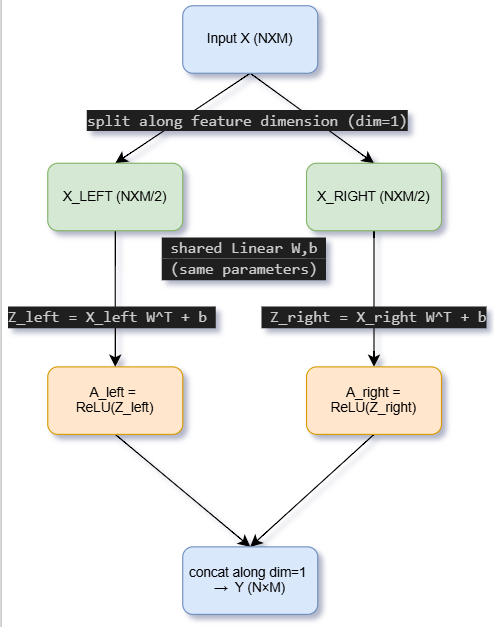


## 1.5 Number of parameters + comparison

Let $M$ be the input feature dimension, and define $d = \frac{M}{2}$.

### Parameters in `SplitLinear`

The shared linear layer maps $\mathbb{R}^{d} \to \mathbb{R}^{d}$, so, Weight matrix $W \in \mathbb{R}^{d \times d}$ has $d^2$ parameters

* Bias vector $b \in \mathbb{R}^{d}$ has $d$ parameters

Total parameters:
$
\text{num(SplitLinear)} = d^2 + d
= \left(\frac{M}{2}\right)^2 + \frac{M}{2}
= \frac{M^2}{4} + \frac{M}{2}.
$

### Parameters in a standard linear layer with the same input/output size

A standard linear layer that maps $\mathbb{R}^{M} \to \mathbb{R}^{M}$ has:

* Weight matrix: $M^2$*,   
* Bias vector: $M$,  
* Total: $\text{num(Linear)} = M^2 + M.$

#### Comparison


$$\text{Ratio (dominant term):}\ \frac{\text{num(SplitLinear)}}{\text{num(Linear)}}=\frac{\frac{M^2}{4} + \frac{M}{2}}{M^2 + M}.\qquad\qquad


\text{For large values of {M}, the quadratic terms dominate, and therefore:}\ \frac{\text{num(SplitLinear)}}{\text{num(Linear)}}\approx\frac{\frac{M^2}{4}}{M^2}=\frac{1}{4}.$$


**Conclusion:**
`SplitLinear` uses approximately **one quarter** of the parameters of a standard ( $M \times M$ ) linear layer, up to lower-order terms.

## 1.6 Analytical gradients w.r.t. $W$ and $b$

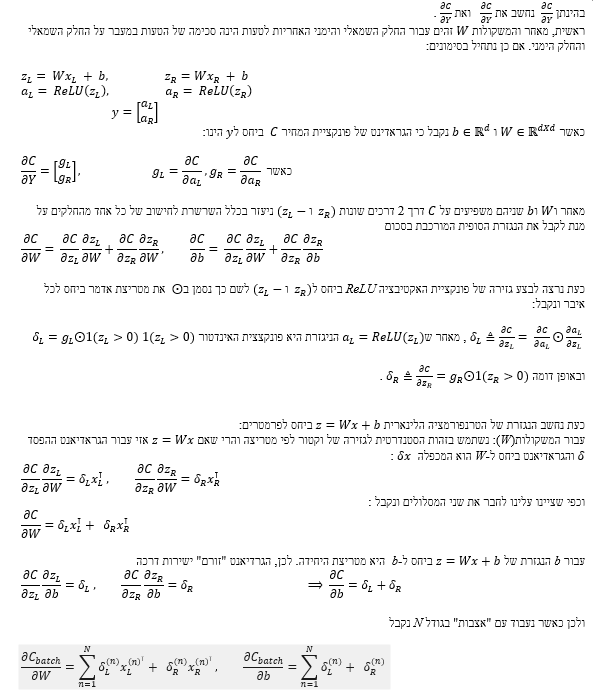

## 1.7 If we split into 4 equal parts instead of 2 (no new calculations)

Let $d_4 = \frac{M}{4}$ and split:
$$
x =
\begin{bmatrix}
x_1 \\
x_2 \\
x_3 \\
x_4
\end{bmatrix},
\qquad
x_i \in \mathbb{R}^{d_4}.
$$

We apply the **same** linear layer and ReLU to each part, so there are **4 branches** contributing to the same parameters. The gradients keep the same structure; they are simply a sum over 4 branches instead of 2.

For one sample:
$$\frac{\partial C}{\partial W} = \sum_{i=1}^{4} \delta_i x_i^{\top},\qquad \frac{\partial C}{\partial b} = \sum_{i=1}^{4} \delta_i,\qquad\
\text{where:}\ \delta_i = g_i \odot \mathbf{1}[z_i > 0].$$

Thus, compared to the two-way split, **two additional terms** are added to each gradient sum—one for each additional split.

# **Question 2**
in this qeustion we will implement by ourselves a dropout layer from scratch called 'DropLayer' that will be used in our prediction task. 

## **2.1**

# DropNorm (Q2.1 – Training forward): Function-by-function explanation

This implementation follows the assignment steps exactly:  
(2) randomly drop **exactly half** the features (same mask for the whole batch),  
(3) compute **per-sample** mean/variance over the **kept** features and normalize,  
(4) apply a learned per-feature affine transform only on kept features, while dropped features remain **0**.  
The forum clarifies that the normalization is **per sample**, not per feature over the batch.

In [3]:
import torch
from torch import nn

# -----------------------------
# Section (2): choose and zero
# -----------------------------

def _broadcast_feature_mask(mask_1d: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    D = x.shape[-1]
    view_shape = [1] * x.ndim
    view_shape[-1] = D
    return mask_1d.view(*view_shape)


def choose_half_features_mask(D: int, device=None) -> torch.Tensor:
    assert D % 2 == 0, "D must be even to keep exactly half."
    perm = torch.randperm(D, device=device)
    keep_idx = perm[: D // 2]
    mask = torch.zeros(D, dtype=torch.bool, device=device)
    mask[keep_idx] = True
    return mask


def apply_feature_dropout(x: torch.Tensor, keep_mask_1d: torch.Tensor) -> torch.Tensor:
    keep_mask_b = _broadcast_feature_mask(keep_mask_1d, x).to(x.dtype)
    return x * keep_mask_b


---

## `_broadcast_feature_mask(mask_1d, x)`

**What it does**  
Takes a 1D boolean feature mask of shape `(D,)` and reshapes it into a broadcastable tensor of shape `(1, 1, ..., 1, D)` matching `x.ndim`.

**Why we need it**  
The assignment requires the *same* feature choice for all samples in the batch. Broadcasting a `(D,)` mask over `(N, ..., D)` ensures:
- the mask applies identically to every sample,
- we can multiply elementwise with `x` regardless of whether `x` is 2D, 3D, etc.  
This supports the requirement that the input can have **any number of dimensions** (batch first, features last).
---

## `choose_half_features_mask(D, device=None)`

**What it does**  
Creates a boolean mask of shape `(D,)` where exactly $`\large\frac{D}{2}`$ entries are `True` (kept features) and the rest are `False` (dropped features). The kept indices are chosen uniformly at random each forward pass.

**Why we need it**  
This is the direct implementation of step (2):  
> “choose randomly … exactly half of the features … and zero them”  
and it must happen **for each forward pass**.
We return a 1D mask so it can be reused consistently across the batch and across later steps (normalization and affine).

---

## `apply_feature_dropout(x, keep_mask_1d)`

**What it does**  
Zeros out the dropped features using the keep mask:
- converts the 1D mask into a broadcastable mask,
- multiplies it into `x`, so dropped features become exactly `0`.

**Why we need it**  
This enforces step (2) explicitly and gives us `x_dropped` where:
- dropped features are *really* zero,
- kept features remain unchanged.  
We also reuse `x_dropped` for step (3), because the statistics must be computed over the features that were **not** zeroed.

In [4]:
# -----------------------------------------
# Section (3): masked per-sample normalization
# -----------------------------------------
def masked_per_sample_stats(x: torch.Tensor, keep_mask_1d: torch.Tensor):
    """
    Compute μ and σ² per sample over kept features only.
    Returns:
      mu  shape (N,...,1)
      var shape (N,...,1)
      keep_mask_b broadcast mask (1,...,1,D) as dtype of x
    """
    D = x.shape[-1]
    assert keep_mask_1d.shape == (D,)
    assert keep_mask_1d.dtype == torch.bool

    keep_mask_b_bool = _broadcast_feature_mask(keep_mask_1d, x)         # bool
    keep_mask_b = keep_mask_b_bool.to(dtype=x.dtype)                    # numeric for sums

    count = keep_mask_1d.sum().to(dtype=x.dtype)                        # scalar = D/2
    # mean over kept dims only
    x_kept = x * keep_mask_b
    mu = x_kept.sum(dim=-1, keepdim=True) / count

    # variance over kept dims only
    dev_kept = (x - mu) * keep_mask_b
    var = (dev_kept ** 2).sum(dim=-1, keepdim=True) / count

    return mu, var, keep_mask_b_bool


def masked_per_sample_normalize(x: torch.Tensor,
                                mu: torch.Tensor,
                                var: torch.Tensor,
                                eps: float) -> torch.Tensor:
    """
    Normalize using provided μ and σ² (per sample).
    xhat = (x - μ) / sqrt(σ² + eps)
    """
    return (x - mu) / torch.sqrt(var + eps)


---

## `masked_per_sample_stats(x, keep_mask_1d)`

**What it does**  
Computes the per-sample mean `mu` and variance `var` over the **kept features only**:
- `mu` has shape `(N, ..., 1)`
- `var` has shape `(N, ..., 1)`
so they broadcast naturally across the last feature dimension.

**Why we need it**  
This is step (3) of the assignment:
- μ and σ² are computed **only** on the features not zeroed,
- and computed **separately for each sample** in the batch. 
The forum explicitly confirms that we normalize **each sample individually**, which is different from BatchNorm.
Keeping `keepdim=True` is critical so the later subtraction/division broadcasts correctly.

---

## `masked_per_sample_normalize(x, mu, var, eps)`

**What it does**  
Computes: $\large{\hat{x} = \LARGE\frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}}$
Elementwise over the full tensor.

**Why we need it**  
This is the normalization formula required by step (3).
Separating it into its own function mirrors the “chapter style” where statistics and normalization are split:
- first compute $\large{\frac{μ}{σ²}}$
- then normalize using them,
which makes debugging and printing intermediate tensors easier.

In [5]:
# --------------------------------
# Section (4): affine over kept only
# --------------------------------
def apply_affine_and_keep_only(xhat: torch.Tensor,
                               gamma: torch.Tensor,
                               beta: torch.Tensor,
                               keep_mask_1d: torch.Tensor) -> torch.Tensor:
    """
    Apply y = gamma * xhat + beta per feature, then force dropped features to 0.
    gamma, beta: shape (D,)
    """
    D = xhat.shape[-1]
    assert gamma.shape == (D,)
    assert beta.shape == (D,)

    # broadcast gamma/beta to (1,...,1,D)
    view_shape = [1] * xhat.ndim
    view_shape[-1] = D
    gamma_b = gamma.view(*view_shape)
    beta_b  = beta.view(*view_shape)

    y = gamma_b * xhat + beta_b

    # ensure dropped features are exactly 0
    keep_mask_b = _broadcast_feature_mask(keep_mask_1d, xhat).to(dtype=xhat.dtype)
    y = y * keep_mask_b
    return y

 ---

## `apply_affine_and_keep_only(xhat, gamma, beta, keep_mask_1d)`

**What it does**  
Applies the learnable per-feature affine transform:
$y = \gamma \hat{x} + \beta$
and then forces dropped features to remain exactly `0` by re-applying the mask.

**Why we need it**  
This is step (4) of the assignment:
- only the non-zeroed (kept) features get the affine transform,
- dropped features “stay 0”.
Re-masking at the end guarantees strict compliance even if numerical operations produce non-zero values in dropped positions.

In [6]:
# =========================
# Final module using helpers
# =========================
class DropNorm(nn.Module):
    def __init__(self, feature_dim: int, eps: float = 1e-5):
        super().__init__()
        self.feature_dim = feature_dim
        self.eps = eps

        # learnable params per feature
        self.gamma = nn.Parameter(torch.ones(feature_dim))
        self.beta  = nn.Parameter(torch.zeros(feature_dim))

        # optional debug
        self.last_keep_mask = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        D = x.shape[-1]
        assert D == self.feature_dim, "Last dimension must equal feature_dim."
        assert D % 2 == 0, "Feature dim must be even."

        if self.training:
            # (2) choose mask + zero-out
            keep_mask = choose_half_features_mask(D, device=x.device)
            self.last_keep_mask = keep_mask
            x_dropped = apply_feature_dropout(x, keep_mask)

            # (3) compute per-sample stats on kept features + normalize
            mu, var, _keep_mask_b_bool = masked_per_sample_stats(x_dropped, keep_mask)
            xhat = masked_per_sample_normalize(x_dropped, mu, var, self.eps)

            # (4) affine on kept only, dropped stay 0
            y = apply_affine_and_keep_only(xhat, self.gamma, self.beta, keep_mask)
            return y

        # inference mode (Section b) — we will implement later
        return x


---

# `DropNorm.forward(x)` (training path)

**What it does**  
Composes the three assignment steps (2)–(4) in order:
1. Choose mask of exactly half the features (`choose_half_features_mask`)
2. Zero out dropped features (`apply_feature_dropout`)
3. Compute per-sample $\large{\frac{μ}{σ²}}$ over kept dims (`masked_per_sample_stats`)
4. Normalize (`masked_per_sample_normalize`)
5. Apply affine on kept dims only and keep dropped = 0 (`apply_affine_and_keep_only`)

**Why we need it**  
The assignment explicitly asks to implement `forward()` in training mode with these operations in this order.
Structuring it as a composition of small functions:
- matches the didactic style used in the guide,
- makes it easier to print and validate each intermediate tensor in the notebook,
- reduces the chance of mixing up broadcasting axes and mask logic.

---

### Q2(b) Inference (eval) forward — design justification

During training, DropNorm randomly zeros exactly half of the feature coordinates (the same mask for the whole batch) and normalizes using statistics computed per sample over the kept (non-zeroed) features. 
In inference, dropout-style randomness should be disabled to obtain deterministic predictions. Therefore, in `eval()` we do not drop any features.  

For the normalization component, the assignment (and the forum clarification) indicates that normalization statistics are computed per sample (not per feature across the batch, unlike BatchNorm).
Hence, in inference we compute mean and variance per sample over all features (since none are dropped), then apply the same normalization formula and the learned affine transform:
$\hat{x}=\frac{x-\mu}{\sqrt{\sigma^2+\epsilon}},  y=\gamma \hat{x}+\beta.$
This makes inference deterministic and consistent with the per-sample normalization principle used in training.

### Q2(c) Constructor and initialization — justification

DropNorm has two learnable parameters per feature coordinate: $\gamma_i$ and $\beta_i$.
We initialize $\gamma$ to ones and $\beta$ to zeros:

$\gamma_i = 1, \beta_i = 0.$
This is a standard and stable choice used in normalization layers, because it makes the initial affine transform an identity:
$y \approx \hat{x}.$

As a result, the layer initially preserves the normalized activations without amplifying or shifting them, which helps training start from a well-conditioned behavior.



## Data Loading (Fashion-MNIST)

In [15]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.notebook import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


def get_fmnist_loaders(batch_size=128, num_workers=2):
    tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.2860,), (0.3530,))])

    train_ds = datasets.FashionMNIST(root="./data", train=True, download=True, transform=tfm)
    test_ds = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tfm)
    
    train_loader = DataLoader( train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True )
    test_loader = DataLoader( test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True )
    
    return train_loader, test_loader


## Models
### Baseline: built-in LayerNorm + Dropout

In [16]:
class BaselineMLP(nn.Module):
    def __init__(self, hidden=256, p=0.3):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, hidden)
        self.ln1 = nn.LayerNorm(hidden)
        self.do1 = nn.Dropout(p)

        self.fc2 = nn.Linear(hidden, hidden)
        self.ln2 = nn.LayerNorm(hidden)
        self.do2 = nn.Dropout(p)

        self.out = nn.Linear(hidden, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.do1(F.relu(self.ln1(self.fc1(x))))
        x = self.do2(F.relu(self.ln2(self.fc2(x))))
        return self.out(x)


### DropNorm model: uses your custom DropNorm (a–c)

In [17]:
class DropNormMLP(nn.Module):
    def __init__(self, hidden=256):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, hidden)
        self.dn1 = DropNorm(feature_dim=hidden)  # your implementation

        self.fc2 = nn.Linear(hidden, hidden)
        self.dn2 = DropNorm(feature_dim=hidden)

        self.out = nn.Linear(hidden, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.dn1(self.fc1(x)))
        x = F.relu(self.dn2(self.fc2(x)))
        return self.out(x)


## Evaluation utilities (with tqdm)

In [18]:
@torch.no_grad()
def eval_metrics(model, loader, device, desc="Eval"):
    model.eval()

    total = 0
    correct = 0
    loss_sum = 0.0

    crit = nn.CrossEntropyLoss(reduction="sum")

    # tqdm wrapper (required)
    for x, y in tqdm(loader, desc=desc, leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss_sum += crit(logits, y).item()

        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()

    return {"loss": loss_sum / total, "acc": correct / total}


## Training utilities (one epoch + full loop, with tqdm)

In [19]:
def train_one_epoch(model, loader, device, opt, crit, desc="Train"):
    model.train()

    total = 0
    correct = 0
    loss_sum = 0.0

    # tqdm wrapper (required)
    pbar = tqdm(loader, desc=desc, leave=False)
    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        opt.zero_grad()
        logits = model(x)
        loss = crit(logits, y)
        loss.backward()
        opt.step()

        bs = y.size(0)
        loss_sum += loss.item() * bs
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += bs

        pbar.set_postfix(loss=loss.item(), lr=opt.param_groups[0]["lr"])

    return {"loss": loss_sum / total, "acc": correct / total}


def train_model_with_history( model, train_loader, test_loader, device, epochs=10, lr=1e-3, run_name="run",):
    model.to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    history = {
        "run_name": run_name,
        "config": {"epochs": epochs, "lr": lr},
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "lr": [],
        "epoch_time_sec": [],
    }

    for ep in range(1, epochs + 1):
        t0 = time.time()

        train_stats = train_one_epoch(
            model, train_loader, device, opt, crit,
            desc=f"{run_name} | Train {ep}/{epochs}"
        )
        test_stats = eval_metrics(
            model, test_loader, device,
            desc=f"{run_name} | Test"
        )

        dt = time.time() - t0
        cur_lr = opt.param_groups[0]["lr"]

        history["train_loss"].append(train_stats["loss"])
        history["train_acc"].append(train_stats["acc"])
        history["test_loss"].append(test_stats["loss"])
        history["test_acc"].append(test_stats["acc"])
        history["lr"].append(cur_lr)
        history["epoch_time_sec"].append(dt)

        print(
            f"{run_name} | Epoch {ep:02d}/{epochs} | "
            f"train_loss={train_stats['loss']:.4f} train_acc={train_stats['acc']:.4f} | "
            f"test_loss={test_stats['loss']:.4f} test_acc={test_stats['acc']:.4f} | "
            f"time={dt:.1f}s"
        )

    return model, history


## Experiment setup (device + loaders)

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
train_loader, test_loader = get_fmnist_loaders(batch_size=128, num_workers=2)

print("Device:", device)
print("Train batches:", len(train_loader), "| Test batches:", len(test_loader))


Device: cpu
Train batches: 469 | Test batches: 79


## Run baseline (LayerNorm + Dropout)

In [21]:
baseline_model = BaselineMLP(hidden=256, p=0.3)
baseline_model, baseline_hist = train_model_with_history(
    baseline_model, train_loader, test_loader, device,
    epochs=10, lr=1e-3, run_name="Baseline(LN+Dropout)"
)


Baseline(LN+Dropout) | Train 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

Baseline(LN+Dropout) | Test:   0%|          | 0/79 [00:00<?, ?it/s]

Baseline(LN+Dropout) | Epoch 01/10 | train_loss=0.5363 train_acc=0.8094 | test_loss=0.4167 test_acc=0.8527 | time=27.9s


Baseline(LN+Dropout) | Train 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

Baseline(LN+Dropout) | Test:   0%|          | 0/79 [00:00<?, ?it/s]

...

Baseline(LN+Dropout) | Test:   0%|          | 0/79 [00:00<?, ?it/s]

Baseline(LN+Dropout) | Epoch 09/10 | train_loss=0.2891 train_acc=0.8923 | test_loss=0.3306 test_acc=0.8821 | time=30.1s


Baseline(LN+Dropout) | Train 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

Baseline(LN+Dropout) | Test:   0%|          | 0/79 [00:00<?, ?it/s]

Baseline(LN+Dropout) | Epoch 10/10 | train_loss=0.2833 train_acc=0.8944 | test_loss=0.3214 test_acc=0.8870 | time=35.9s


## Run DropNorm model

In [22]:
dropnorm_model = DropNormMLP(hidden=256)
dropnorm_model, dropnorm_hist = train_model_with_history(
    dropnorm_model, train_loader, test_loader, device,
    epochs=10, lr=1e-3, run_name="DropNorm"
)


DropNorm | Train 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

DropNorm | Test:   0%|          | 0/79 [00:00<?, ?it/s]

DropNorm | Epoch 01/10 | train_loss=0.7318 train_acc=0.7504 | test_loss=1.3354 test_acc=0.8215 | time=33.4s


DropNorm | Train 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

DropNorm | Test:   0%|          | 0/79 [00:00<?, ?it/s]

...

DropNorm | Test:   0%|          | 0/79 [00:00<?, ?it/s]

DropNorm | Epoch 09/10 | train_loss=0.3723 train_acc=0.8652 | test_loss=3.4665 test_acc=0.8613 | time=30.4s


DropNorm | Train 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

DropNorm | Test:   0%|          | 0/79 [00:00<?, ?it/s]

DropNorm | Epoch 10/10 | train_loss=0.3579 train_acc=0.8684 | test_loss=3.7001 test_acc=0.8644 | time=29.6s


## Final comparison summary

In [23]:
print("\n=== Final comparison ===")
print(f"Baseline final test_acc: {baseline_hist['test_acc'][-1]:.4f}")
print(f"DropNorm final test_acc: {dropnorm_hist['test_acc'][-1]:.4f}")
print(f"Gap (Baseline - DropNorm): {(baseline_hist['test_acc'][-1] - dropnorm_hist['test_acc'][-1]):.4f}")



=== Final comparison ===
Baseline final test_acc: 0.8870
DropNorm final test_acc: 0.8644
Gap (Baseline - DropNorm): 0.0226


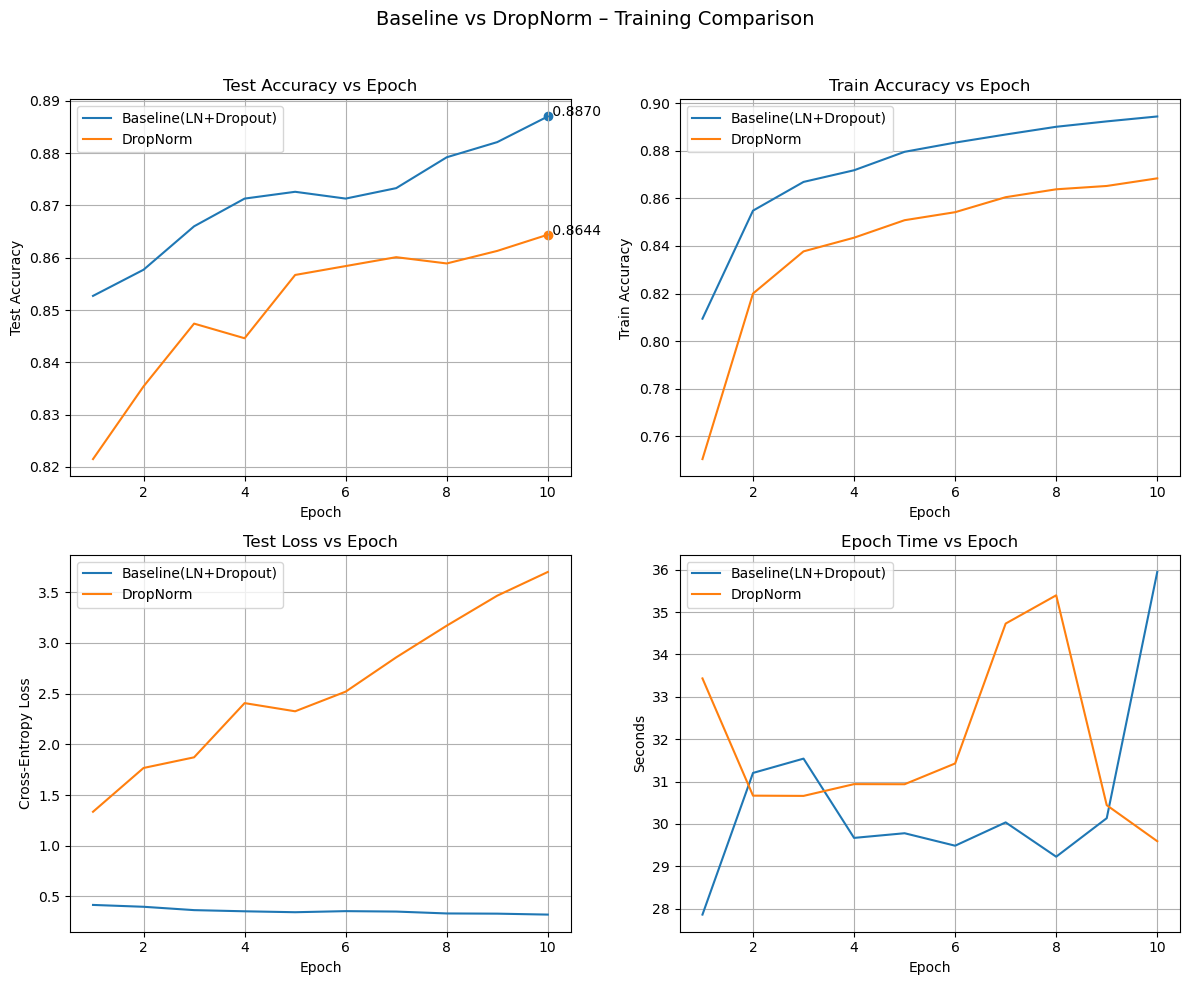

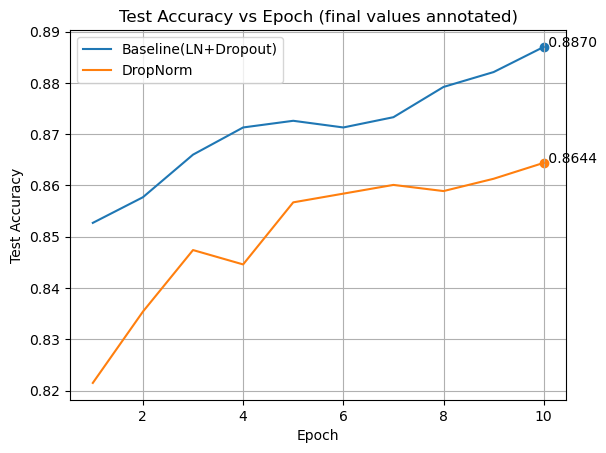

In [27]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(baseline_hist["test_acc"]) + 1))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Baseline vs DropNorm – Training Comparison", fontsize=14)

# -------------------------------------------------
# (1) Test Accuracy (annotated) — TOP LEFT
# -------------------------------------------------
ax = axes[0, 0]
ax.plot(epochs, baseline_hist["test_acc"], label=baseline_hist["run_name"])
ax.plot(epochs, dropnorm_hist["test_acc"], label=dropnorm_hist["run_name"])

ax.scatter(epochs[-1], baseline_hist["test_acc"][-1])
ax.scatter(epochs[-1], dropnorm_hist["test_acc"][-1])

ax.text(epochs[-1], baseline_hist["test_acc"][-1],
        f" {baseline_hist['test_acc'][-1]:.4f}")
ax.text(epochs[-1], dropnorm_hist["test_acc"][-1],
        f" {dropnorm_hist['test_acc'][-1]:.4f}")

ax.set_title("Test Accuracy vs Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Accuracy")
ax.legend()
ax.grid(True)

# -------------------------------------------------
# (2) Train Accuracy — TOP RIGHT
# -------------------------------------------------
ax = axes[0, 1]
ax.plot(epochs, baseline_hist["train_acc"], label=baseline_hist["run_name"])
ax.plot(epochs, dropnorm_hist["train_acc"], label=dropnorm_hist["run_name"])

ax.set_title("Train Accuracy vs Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Train Accuracy")
ax.legend()
ax.grid(True)

# -------------------------------------------------
# (3) Test Loss — BOTTOM LEFT
# -------------------------------------------------
ax = axes[1, 0]
ax.plot(epochs, baseline_hist["test_loss"], label=baseline_hist["run_name"])
ax.plot(epochs, dropnorm_hist["test_loss"], label=dropnorm_hist["run_name"])

ax.set_title("Test Loss vs Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend()
ax.grid(True)

# -------------------------------------------------
# (4) Epoch Time — BOTTOM RIGHT
# -------------------------------------------------
ax = axes[1, 1]
ax.plot(epochs, baseline_hist["epoch_time_sec"], label=baseline_hist["run_name"])
ax.plot(epochs, dropnorm_hist["epoch_time_sec"], label=dropnorm_hist["run_name"])

ax.set_title("Epoch Time vs Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Seconds")
ax.legend()
ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

plt.figure()
epochs = list(range(1, len(baseline_hist["test_acc"]) + 1))
plt.plot(epochs, baseline_hist["test_acc"], label=baseline_hist["run_name"])
plt.plot(epochs, dropnorm_hist["test_acc"], label=dropnorm_hist["run_name"])

plt.scatter([epochs[-1]], [baseline_hist["test_acc"][-1]])
plt.scatter([epochs[-1]], [dropnorm_hist["test_acc"][-1]])

plt.text(epochs[-1], baseline_hist["test_acc"][-1], f" {baseline_hist['test_acc'][-1]:.4f}")
plt.text(epochs[-1], dropnorm_hist["test_acc"][-1], f" {dropnorm_hist['test_acc'][-1]:.4f}")

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Epoch (final values annotated)")
plt.legend()
plt.grid(True)
plt.show()

### 2.6 Comparison of Results and Preferred Network

Both networks were trained using the same architecture and training setup, differing only in the normalization and regularization layers. The first network used PyTorch’s built-in **LayerNorm and Dropout**, while the second replaced these layers with the custom **DropNorm** layer implemented in the previous sections.

The experimental results show that the network using the built-in layers consistently outperformed the DropNorm-based network throughout training. The baseline model converged faster and achieved a higher final test accuracy of **88.7%**, compared to **86.4%** for the DropNorm model, resulting in a performance gap of approximately **2.3%** in favor of the baseline. This gap was stable across epochs, indicating better generalization.

In addition, the training dynamics of the DropNorm network were less stable. While training accuracy increased steadily, the test loss was significantly higher and increased over epochs, suggesting that the aggressive random removal of half of the feature dimensions during training makes optimization more difficult. In contrast, the built-in LayerNorm and Dropout layers produced smoother loss curves and more stable convergence.

Based on these observations, the preferred network is the one using **PyTorch’s built-in normalization and dropout layers**. It achieves higher accuracy, converges faster, and exhibits more stable training behavior. Nevertheless, this experiment demonstrates that DropNorm is a valid regularization mechanism, though in this setting it is less effective than the standard, well-established alternatives.


## Q2.7: Analytical backprop through DropNorm for input shape $X\in\mathbb{R}^{N\times4}$

We are given the upstream gradient $\frac{\partial C}{\partial Y}$ and are asked to compute $\frac{\partial C}{\partial x_i}$ for each feature $i$.
The computation is performed **independently for each sample** in the batch.

---

### Forward definition (training mode)

For a single sample $x\in\mathbb{R}^4$, the layer keeps exactly two features.
Let $K\subset{1,2,3,4}$ with $|K|=m=2$, and let $D={1,2,3,4}\setminus K$.

1. **Drop (mask):**
   If $i\in D$, the feature is set to zero and remains zero in the output.

2. **Statistics over kept features:**
   $\large
   \mu=\frac{1}{m}\sum_{k\in K}x_k,\qquad
   \sigma^2=\frac{1}{m}\sum_{k\in K}(x_k-\mu)^2,\qquad
   s=\sqrt{\sigma^2+\varepsilon}.
   $

3. **Normalization:**
   $\large
   \hat{x}_i=\frac{x_i-\mu}{s}\quad\text{for }i\in K.
   $

4. **Affine transform:**
   $\large
   y_i=
   \begin{cases}
   \gamma_i\hat{x}_i+\beta_i, & i\in K \
   0, & i\in D
   \end{cases}
   $

---

### Given upstream gradient

Let
$\large g_i=\frac{\partial C}{\partial y_i}$ be the given upstream gradient.

For kept features:
$\large \frac{\partial C}{\partial \hat{x}_i}=g_i,\gamma_i,\qquad
d_i\equiv g_i,\gamma_i \quad\text{for } i\in K.$

---

 Result: $\frac{\partial C}{\partial x_i}$

#### 1) Dropped features

Since $\ y_i=0$ does not depend on $\ x_i$:

$$ \boxed{\frac{\partial C}{\partial x_i}=0\qquad\text{for }i\in D.}$$

#### 2) Kept features

Define the averages over the kept set ($m=2$):
$\large
\overline{d}=\frac{1}{m}\sum_{k\in K}d_k,\qquad
\overline{d\hat{x}}=\frac{1}{m}\sum_{k\in K}d_k\hat{x}_k.
$

Then for $i\in K$ the gradient is:
$\large
\boxed{
\frac{\partial C}{\partial x_i}=
\frac{1}{s}\left(
d_i-\overline{d}-\hat{x}_i,\overline{d\hat{x}}
\right)
\qquad\text{for } i\in K.
}
$

---

### Extension to the batch

The same computation is applied **row-wise** for each sample in $X$.
The mask $K$ is shared across the batch for a given forward pass, while $\mu$ and $\sigma^2$ are computed per sample. Therefore:
$\large
\left(\frac{\partial C}{\partial X}\right)_{n,i}=
\frac{\partial C}{\partial x^{(n)}_i}.
$

Thus, $\frac{\partial C}{\partial X}\in\mathbb{R}^{N\times4}$ has zeros on dropped coordinates and the expression above on kept coordinates.

## Summary

In this assignment, we studied normalization and regularization mechanisms in deep neural networks from both a theoretical and practical perspective. We designed and implemented a custom normalization layer, **DropNorm**, which combines feature dropping with per-sample normalization, and analyzed its behavior during training and inference. The forward pass was carefully defined to randomly drop exactly half of the input features while normalizing the remaining features, and the backward pass was derived analytically, showing that gradients propagate only through the kept features in a LayerNorm-like manner.

We then evaluated the effectiveness of DropNorm empirically by training a deep neural network on the Fashion-MNIST dataset. Its performance was compared against a baseline network using PyTorch’s built-in LayerNorm and Dropout layers. While both networks learned meaningful representations, the baseline model consistently achieved higher test accuracy, faster convergence, and more stable training dynamics. The DropNorm model exhibited slightly weaker generalization, likely due to the aggressive feature dropping performed at each forward pass.

Overall, this work demonstrates that DropNorm is a valid and mathematically sound normalization scheme, and that its behavior aligns with the theoretical gradient analysis. However, in practice, well-established normalization and regularization layers provide better performance and stability on this task. The combination of analytical derivations and empirical evaluation highlights the importance of both theoretical correctness and practical effectiveness when designing new neural network layers.
